In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [5]:
df = pd.read_csv("customer_churn_10_features_100_rows.csv")

print(df.head())

   CustomerID  Gender  SeniorCitizen Partner Dependents  Tenure  \
0           1    Male              0      No        Yes      29   
1           2    Male              0     Yes        Yes      30   
2           3    Male              1      No        Yes      21   
3           4    Male              1     Yes        Yes      49   
4           5  Female              0      No        Yes      71   

  InternetService TechSupport  Contract  MonthlyCharges Churn  
0             DSL         Yes  Two Year             656   Yes  
1              No         Yes  Two Year            1114   Yes  
2              No          No  One Year            1438    No  
3             DSL          No  One Year            1383    No  
4     Fiber Optic          No  Two Year            1087    No  


In [6]:
print("\nDataset Shape")
print(df.shape)

print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())


Dataset Shape
(100, 11)

Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CustomerID       100 non-null    int64
 1   Gender           100 non-null    str  
 2   SeniorCitizen    100 non-null    int64
 3   Partner          100 non-null    str  
 4   Dependents       100 non-null    str  
 5   Tenure           100 non-null    int64
 6   InternetService  100 non-null    str  
 7   TechSupport      100 non-null    str  
 8   Contract         100 non-null    str  
 9   MonthlyCharges   100 non-null    int64
 10  Churn            100 non-null    str  
dtypes: int64(4), str(7)
memory usage: 8.7 KB
None

Missing Values
CustomerID         0
Gender             0
SeniorCitizen      0
Partner            0
Dependents         0
Tenure             0
InternetService    0
TechSupport        0
Contract           0
MonthlyCharges     0
Churn              

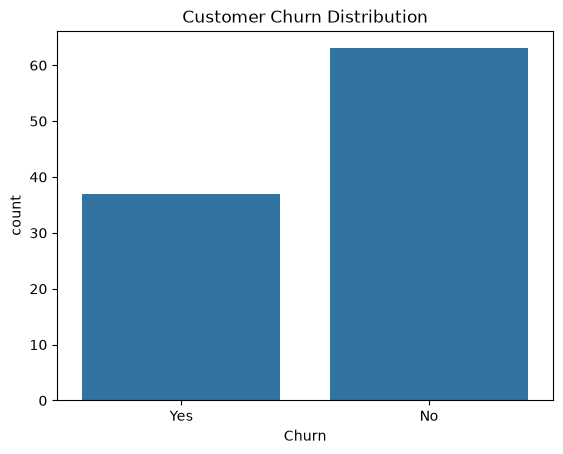

In [7]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()

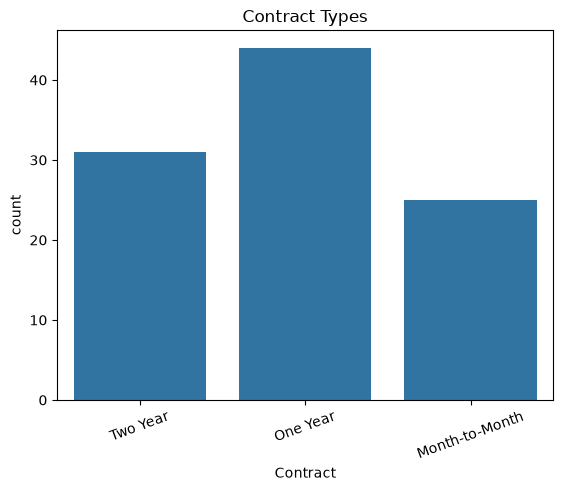

In [8]:
sns.countplot(x="Contract", data=df)

plt.title("Contract Types")
plt.xticks(rotation=20)
plt.show()

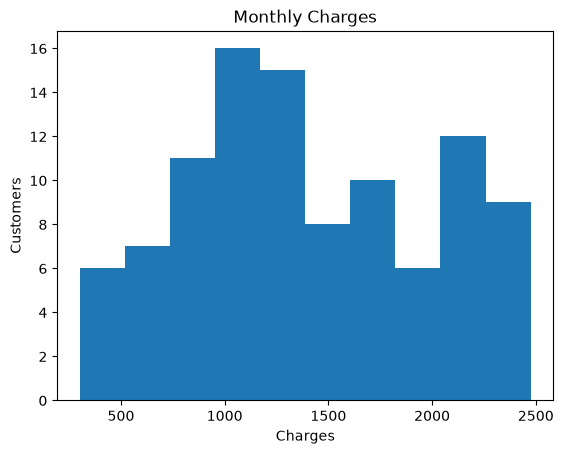

In [9]:
plt.hist(df["MonthlyCharges"], bins=10)

plt.title("Monthly Charges")
plt.xlabel("Charges")
plt.ylabel("Customers")

plt.show()

In [10]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df["Partner"] = encoder.fit_transform(df["Partner"])

df["Dependents"] = encoder.fit_transform(df["Dependents"])

df["InternetService"] = encoder.fit_transform(df["InternetService"])

df["TechSupport"] = encoder.fit_transform(df["TechSupport"])

df["Contract"] = encoder.fit_transform(df["Contract"])

df["Churn"] = encoder.fit_transform(df["Churn"])

In [11]:
X = df.drop(["CustomerID", "Churn"], axis=1)

y = df["Churn"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [14]:
y_pred = model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)


Accuracy: 0.5


In [16]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")

print(cm)


Confusion Matrix
[[7 5]
 [5 3]]


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.58      0.58        12
           1       0.38      0.38      0.38         8

    accuracy                           0.50        20
   macro avg       0.48      0.48      0.48        20
weighted avg       0.50      0.50      0.50        20



In [18]:
new_customer = [[
    1,      # Gender
    0,      # SeniorCitizen
    1,      # Partner
    0,      # Dependents
    5,      # Tenure
    1,      # InternetService
    0,      # TechSupport
    0,      # Contract
    1800    # MonthlyCharges
]]

prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Customer Will Churn")
else:
    print("Customer Will Stay")

Customer Will Churn


C:\Users\anjal\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
